In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

In [4]:
#Function to load data
def load_house_data():
    data = np.loadtxt("./data/houses.txt", delimiter = ",", skiprows = 1)
    X = data[:, : 4]
    y = data[:, 4]
    return X, y

# Gradient Descent

## Loda the Data Set

In [6]:
X_train, y_train = load_house_data()
X_features = ["size (sq. ft.)", "bedrooms", "floors", "age"]

## Scale/Normalize the Training Data

In [8]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)
print(f"Peak to Peak range by column in raw X: {np.ptp(X_train, axis = 0)}")
print(f"Peak to Peak range by column in Normalized X: {np.ptp(X_norm, axis = 0)}")

Peak to Peak range by column in raw X: [2.406e+03 4.000e+00 1.000e+00 9.500e+01]
Peak to Peak range by column in Normalized X: [5.8452591  6.13529646 2.05626214 3.68533012]


## Create and Fit Regression Model

In [10]:
sgdr = SGDRegressor(max_iter = 1000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f"No. of iterations completed: {sgdr.n_iter_}, No. of weighets updated: {sgdr.t_}")

SGDRegressor()
No. of iterations completed: 127, No. of weighets updated: 12574.0


## View Parameters

In [12]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"Model Parameters: w: {w_norm}, b: {b_norm}")

Model Parameters: w: [110.12797143 -21.10875546 -32.51908335 -38.04333245], b: [363.16105198]


## Make Predictions

In [18]:
#make the prediction using sgdr.predict()
y_pred_sgdr = sgdr.predict(X_norm)

#make prediction using w, b
y_pred = np.dot(X_norm, w_norm) + b_norm
print(f"Prediction using np.dot() and sdgr.predict() match: {(y_pred_sgdr == y_pred).all()}")
print(f"Prediction on training set: \n {y_pred[:4]}")
print(f"Target values: {y_train[:4]}")

Prediction using np.dot() and sdgr.predict() match: True
Prediction on training set: 
 [295.21185241 485.79531394 389.50377474 491.95754614]
Target values: [300.  509.8 394.  540. ]


## Plot Results

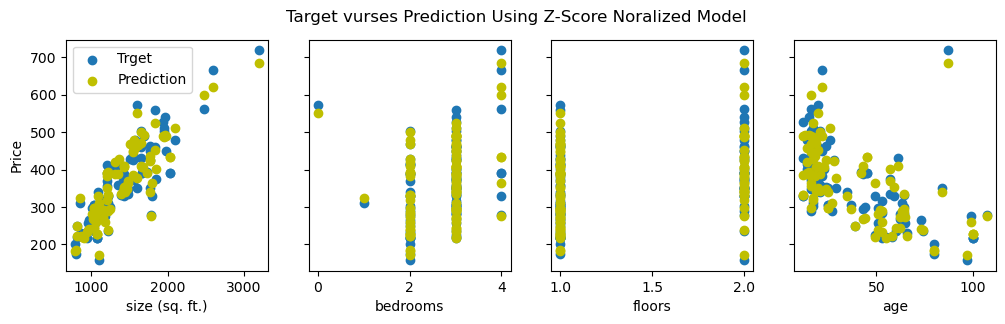

In [59]:
fig, ax = plt.subplots(1, 4, figsize = (12, 3), sharey = True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train, label = "Trget")
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:, i], y_pred, color = 'y', label = "Prediction")
ax[0].set_ylabel("Price")
ax[0].legend()
fig.suptitle("Target vurses Prediction Using Z-Score Noralized Model")
plt.show()